In [21]:
import os
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from keras.optimizers import Adam, SGD
from keras.preprocessing.image import ImageDataGenerator
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV


In [ ]:


# Constants
IM_WIDTH, IM_HEIGHT = 224, 224
NB_EPOCHS = 10
BAT_SIZE = 32
NUM_CLASSES = 5  # Number of snake classes

# Dataset folders
train_dir = "Dataset/Train"
val_dir = "Dataset/Val"
test_dir = "Dataset/Test"

# Define the model creation function
def create_model(optimizer='adam', learning_rate=0.001):
    if optimizer == 'adam':
        optimizer = Adam(learning_rate=learning_rate)
    elif optimizer == 'sgd':
        optimizer = SGD(learning_rate=learning_rate)

    model = Sequential()
    model.add(Conv2D(32, (3, 3), input_shape=(IM_WIDTH, IM_HEIGHT, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(NUM_CLASSES, activation='softmax'))

    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Data augmentation and preprocessing
train_datagen = ImageDataGenerator(rescale=1./255, shear_range=0.2, zoom_range=0.2)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IM_WIDTH, IM_HEIGHT),
    batch_size=BAT_SIZE,
    class_mode='categorical'
)

validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IM_WIDTH, IM_HEIGHT),
    batch_size=BAT_SIZE,
    class_mode='categorical'
)

# Custom wrapper function for KerasClassifier
def create_keras_classifier(optimizer='adam', learning_rate=0.001):
    return KerasClassifier(build_fn=create_model, optimizer=optimizer, learning_rate=learning_rate, epochs=NB_EPOCHS, batch_size=BAT_SIZE, verbose=0)

# Define the hyperparameter grid
param_grid = {
    'optimizer': ['adam', 'sgd'],
    'learning_rate': [0.001, 0.0001, 0.00001],
}

# Use GridSearchCV for hyperparameter tuning
grid = GridSearchCV(estimator=create_keras_classifier(), param_grid=param_grid, cv=2)
grid_result = grid.fit(train_generator, validation_data=validation_generator)

# Print the best hyperparameters
best_params = grid_result.best_params_
print("Best Hyperparameters:", best_params)

# Plot training and validation accuracy
plt.plot(grid_result.best_estimator_.model.history.history['accuracy'], label='Training Accuracy')
plt.plot(grid_result.best_estimator_.model.history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Save the model
grid_result.best_estimator_.model.save("snake_breed_model.h5")


Found 9290 images belonging to 5 classes.
Found 143 images belonging to 5 classes.


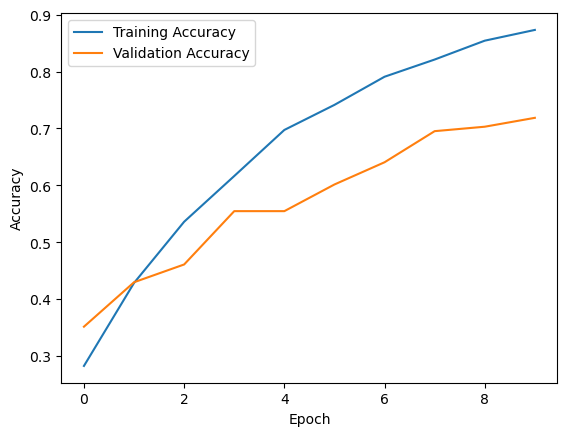

In [4]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [5]:
model.save("snake_breed_model.h5")

C:\Users\Sandusha\anaconda3\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
